In [7]:
import openslide
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

In [63]:
roi_folder = "/Volumes/rsrch5/home/trans_mol_path/cercan/BE_master/0.input/flow/roi/flow/threshold_pyramid/"

In [70]:
WSI_path = os.path.join(roi_folder,"D0893_ROI1.tif")
WSI = openslide.OpenSlide(WSI_path)



In [71]:
level = WSI.get_best_level_for_downsample(32)

img_rgb = np.array(WSI.read_region((0,0), level, WSI.level_dimensions[level]).convert('RGB'))
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
img_blur = cv2.GaussianBlur(img_gray,(3,3),0)
_, img_otsu = cv2.threshold(img_blur, 10, 255, cv2.THRESH_OTSU+cv2.THRESH_BINARY_INV)
_, mask_ink = cv2.threshold(img_gray, 40, 255, cv2.THRESH_BINARY_INV)
dilate_kernel = np.ones((3,3), np.uint8)
mask_ink = cv2.dilate(mask_ink, dilate_kernel, iterations=1)
mask_foreground = cv2.subtract(img_otsu, mask_ink)

(-0.5, 118.5, 395.5, -0.5)

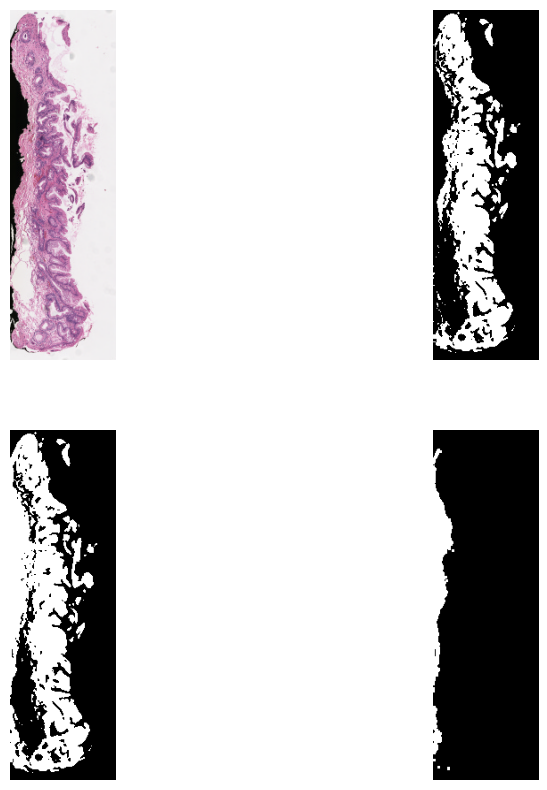

In [72]:

# Create a figure and a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Display the images
axs[0, 0].imshow(img_rgb)
axs[0, 0].axis('off')
axs[0, 1].imshow(mask_foreground, cmap='gray')
axs[0, 1].axis('off')
axs[1, 0].imshow(img_otsu, cmap='gray')
axs[1, 0].axis('off')
axs[1, 1].imshow(mask_ink, cmap='gray')
axs[1, 1].axis('off')